# Credit Risk Scoring & Expected Loss Analysis
## Notebook 5: Expected Loss Scenario Analysis

This notebook translates model-predicted Probabilities of Default (PD) into a financial impact estimate using the Basel-standard **Expected Loss** formula:

$$EL = PD \times LGD \times Exposure\ Proxy$$

### Important methodology disclosures

This analysis is a **simplified illustrative scenario**, not a production-grade Basel IRB calculation. The following limitations apply:

| Component | What is used | What would be required in practice |
|---|---|---|
| **PD** | Model-predicted probability (uncalibrated) | Calibrated, through-the-cycle PD from validated scorecard |
| **LGD** | Fixed 45% industry assumption | Empirically estimated from historical recovery data |
| **EAD (Exposure)** | `LIMIT_BAL` (approved credit limit) — **a proxy only** | Outstanding balance + estimated draw-down at time of default |

The dataset does not provide observed EAD at time of default, empirical recovery rates, or outstanding balance at default. All three components therefore rely on simplifying assumptions.

## 1. Imports & Load Predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

PREDICTIONS_PATH = '../data/processed/test_predictions.csv'
FIGURES_DIR      = '../figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load predictions saved by Notebook 4
df = pd.read_csv(PREDICTIONS_PATH)
print(f'Loaded predictions: {df.shape[0]:,} test-set clients')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Loaded predictions: 6,000 test-set clients
Columns: ['Actual_Default', 'Credit_Limit', 'PD_LR', 'PD_RF']


,Actual_Default,Credit_Limit,PD_LR,PD_RF
0,0,50000,0.319319,0.317913
1,0,150000,0.344057,0.380950
2,0,50000,0.494616,0.372909


## 2. EAD — Exposure Proxy

### Terminology note

**Exposure at Default (EAD)** is the outstanding credit balance at the exact moment a borrower defaults. This dataset does not contain observed EAD data.

**`LIMIT_BAL`** is the **approved credit card limit** — the maximum amount the client is authorised to borrow. It is used here as an upper-bound exposure proxy because:

- It is consistently available for all clients
- It represents the institution's maximum contractual exposure
- It is a common simplifying assumption in retail credit EL exercises

**Limitation**: Clients who have not drawn their full credit line will have actual EAD below `LIMIT_BAL`. Using the full credit limit therefore **overstates** expected exposure for under-utilised accounts. In practice, EAD models also incorporate Credit Conversion Factors (CCFs) applied to the undrawn portion.

In [2]:
# Rename for clarity — explicitly NOT calling this 'EAD'
df['Exposure_Proxy'] = df['Credit_Limit']   # LIMIT_BAL as upper-bound proxy

total_exposure_proxy = df['Exposure_Proxy'].sum()
print(f'Test portfolio total exposure proxy (sum of LIMIT_BAL): NTD {total_exposure_proxy:,.0f}')
print(f'Average exposure proxy per client:                       NTD {df["Exposure_Proxy"].mean():,.0f}')
print()
print('Note: LIMIT_BAL is the approved credit limit, not the outstanding balance.')
print('This is an upper-bound proxy for EAD, not an observed EAD value.')

Test portfolio total exposure proxy (sum of LIMIT_BAL): NTD 1,007,777,680
Average exposure proxy per client:                       NTD 167,963

Note: LIMIT_BAL is the approved credit limit, not the outstanding balance.
This is an upper-bound proxy for EAD, not an observed EAD value.


## 3. LGD — Loss Given Default Assumption

**Loss Given Default (LGD)** is the fraction of the outstanding exposure that is ultimately lost when a borrower defaults (after recovery).

The dataset contains no recovery data. A fixed **45% LGD assumption** is applied, which:

- Is consistent with Basel II/III benchmarks for unsecured consumer credit (retail)
- Is within the typical empirical range of 40–75% reported in academic literature for unsecured revolving credit
- Is labelled explicitly as an assumption throughout this analysis

A sensitivity analysis below shows how EL estimates change across a range of LGD assumptions.

In [3]:
LGD_ASSUMPTION = 0.45   # 45% — illustrative assumption for unsecured consumer credit

print(f'LGD assumption: {LGD_ASSUMPTION:.0%}')
print('Source: Illustrative assumption consistent with Basel retail unsecured benchmarks.')
print('This value is NOT estimated from empirical recovery data in this dataset.')

LGD assumption: 45%
Source: Illustrative assumption consistent with Basel retail unsecured benchmarks.
This value is NOT estimated from empirical recovery data in this dataset.


## 4. Expected Loss Calculation

$$EL = PD \times LGD \times Exposure\ Proxy$$

Calculated separately for both the Logistic Regression and Random Forest PD estimates.

In [4]:
df['EL_LR'] = df['PD_LR'] * LGD_ASSUMPTION * df['Exposure_Proxy']
df['EL_RF'] = df['PD_RF'] * LGD_ASSUMPTION * df['Exposure_Proxy']

total_el_lr = df['EL_LR'].sum()
total_el_rf = df['EL_RF'].sum()

print('=== Expected Loss Scenario Analysis ===')
print(f'EL formula: PD x LGD({LGD_ASSUMPTION:.0%}) x Exposure Proxy (LIMIT_BAL)')
print()
print(f'Total Exposure Proxy (sum of LIMIT_BAL): NTD {total_exposure_proxy:>18,.0f}')
print(f'Expected Loss — Logistic Regression:     NTD {total_el_lr:>18,.0f}  ({total_el_lr/total_exposure_proxy*100:.2f}%)')
print(f'Expected Loss — Random Forest:           NTD {total_el_rf:>18,.0f}  ({total_el_rf/total_exposure_proxy*100:.2f}%)')
print()
print('CAUTION: The EL/Exposure ratio exceeds the observed default rate (22.12%) because')
print('class_weight="balanced" inflates model-predicted PDs above the true base rate.')
print('These figures are illustrative scenario estimates, not production EL forecasts.')

=== Expected Loss Scenario Analysis ===
EL formula: PD x LGD(45%) x Exposure Proxy (LIMIT_BAL)

Total Exposure Proxy (sum of LIMIT_BAL): NTD      1,007,777,680
Expected Loss — Logistic Regression:     NTD        172,988,073  (17.17%)
Expected Loss — Random Forest:           NTD        160,805,361  (15.96%)

CAUTION: The EL/Exposure ratio exceeds the observed default rate (22.12%) because
class_weight="balanced" inflates model-predicted PDs above the true base rate.
These figures are illustrative scenario estimates, not production EL forecasts.


## 5. Risk Tier Segmentation

Clients are classified into **three risk tiers** based on predicted PD from the Random Forest model. The thresholds are **project-defined illustrative boundaries** — not regulatory capital bands:

| Tier | PD Range | Interpretation |
|---|---|---|
| **Low** | PD < 20% | Below-average default probability; monitor normally |
| **Medium** | 20% ≤ PD < 40% | Elevated risk; enhanced monitoring warranted |
| **High** | PD ≥ 40% | High default probability; potential for early intervention |

> These thresholds are chosen for illustration. A production system would derive tier boundaries from business rules, regulatory requirements, or quantile-based calibration.

In [5]:
TIER_LOW  = 0.20
TIER_HIGH = 0.40

def assign_risk_tier(pd_value):
    """Assign client to illustrative risk tier based on predicted PD."""
    if pd_value < TIER_LOW:
        return 'Low'
    elif pd_value < TIER_HIGH:
        return 'Medium'
    else:
        return 'High'

df['Risk_Tier'] = df['PD_RF'].apply(assign_risk_tier)

tier_order = ['Low', 'Medium', 'High']
tier_summary = df.groupby('Risk_Tier').agg(
    Customer_Count       = ('Actual_Default', 'count'),
    Avg_Predicted_PD     = ('PD_RF', 'mean'),
    Observed_Default_Rate= ('Actual_Default', 'mean'),
    Avg_Exposure_Proxy   = ('Exposure_Proxy', 'mean'),
    Total_EL_RF          = ('EL_RF', 'sum')
).reindex(tier_order)

tier_summary['Avg_Predicted_PD_Pct']      = (tier_summary['Avg_Predicted_PD']      * 100).round(1)
tier_summary['Observed_Default_Rate_Pct'] = (tier_summary['Observed_Default_Rate'] * 100).round(1)

display_cols = [
    'Customer_Count', 'Avg_Predicted_PD_Pct',
    'Observed_Default_Rate_Pct', 'Avg_Exposure_Proxy', 'Total_EL_RF'
]

print('=== Risk Tier Segmentation (RF PD, Illustrative Thresholds) ===')
print(f'  Low:    PD < {TIER_LOW:.0%}')
print(f'  Medium: {TIER_LOW:.0%} <= PD < {TIER_HIGH:.0%}')
print(f'  High:   PD >= {TIER_HIGH:.0%}')
print()
print(tier_summary[display_cols].to_string())
print()
for tier in tier_order:
    count = tier_summary.loc[tier, 'Customer_Count']
    pct   = count / len(df) * 100
    print(f'  {tier:8s}: {count:,} clients ({pct:.1f}%)')

=== Risk Tier Segmentation (RF PD, Illustrative Thresholds) ===
  Low:    PD < 20%
  Medium: 20% <= PD < 40%
  High:   PD >= 40%

           Customer_Count  Avg_Predicted_PD_Pct  Observed_Default_Rate_Pct  Avg_Exposure_Proxy   Total_EL_RF
Risk_Tier                                                                                                   
Low                   511                  17.1                        4.3       321017.612524  1.243192e+07
Medium               3068                  30.0                       11.8       183158.409387  7.261375e+07
High                 2421                  61.8                       39.0       116401.354812  7.575969e+07

  Low     : 511 clients (8.5%)
  Medium  : 3,068 clients (51.1%)
  High    : 2,421 clients (40.4%)


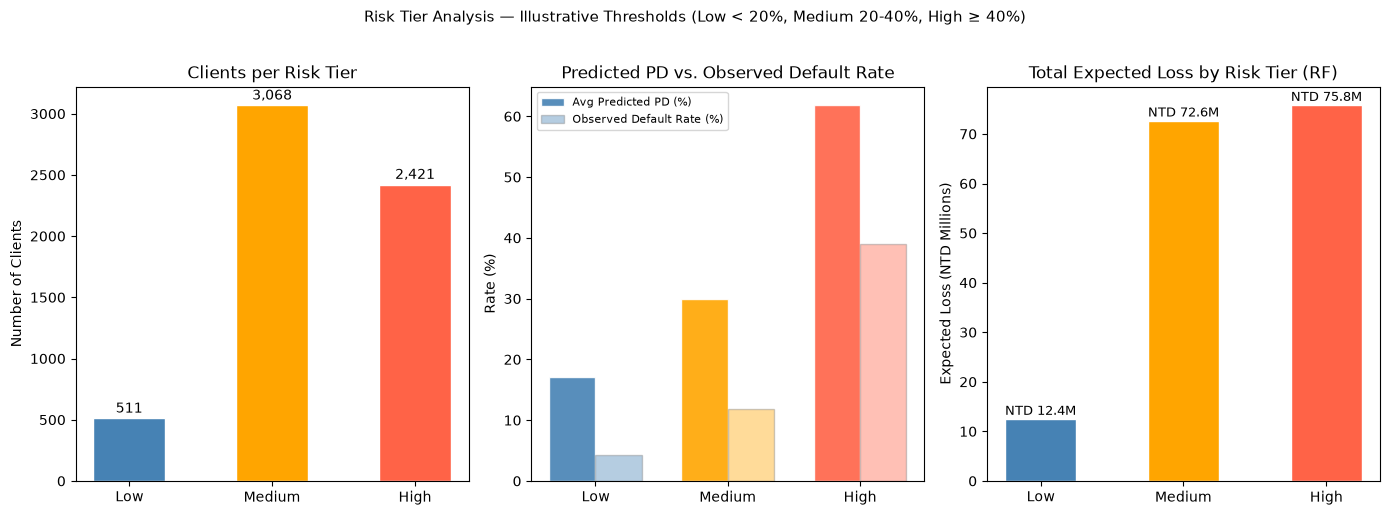

Figure saved to figures/risk_tier_analysis.png


In [6]:
# Risk tier visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = {'Low': 'steelblue', 'Medium': 'orange', 'High': 'tomato'}
color_list = [colors[t] for t in tier_order]

# Chart 1: Customer count
counts = [tier_summary.loc[t, 'Customer_Count'] for t in tier_order]
axes[0].bar(tier_order, counts, color=color_list, edgecolor='white', width=0.5)
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Clients per Risk Tier')
axes[0].set_ylabel('Number of Clients')

# Chart 2: Predicted PD vs Observed default rate
pred_pds  = [tier_summary.loc[t, 'Avg_Predicted_PD_Pct'] for t in tier_order]
obs_rates = [tier_summary.loc[t, 'Observed_Default_Rate_Pct'] for t in tier_order]
x = np.arange(len(tier_order))
width = 0.35
axes[1].bar(x - width/2, pred_pds,  width, label='Avg Predicted PD (%)',     color=color_list, alpha=0.9, edgecolor='white')
axes[1].bar(x + width/2, obs_rates, width, label='Observed Default Rate (%)', color=color_list, alpha=0.4, edgecolor='grey')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tier_order)
axes[1].set_title('Predicted PD vs. Observed Default Rate')
axes[1].set_ylabel('Rate (%)')
axes[1].legend(fontsize=8)

# Chart 3: Expected Loss by tier
el_vals = [tier_summary.loc[t, 'Total_EL_RF'] / 1e6 for t in tier_order]
axes[2].bar(tier_order, el_vals, color=color_list, edgecolor='white', width=0.5)
for i, v in enumerate(el_vals):
    axes[2].text(i, v + 0.3, f'NTD {v:.1f}M', ha='center', va='bottom', fontsize=9)
axes[2].set_title('Total Expected Loss by Risk Tier (RF)')
axes[2].set_ylabel('Expected Loss (NTD Millions)')

plt.suptitle('Risk Tier Analysis — Illustrative Thresholds (Low < 20%, Medium 20-40%, High ≥ 40%)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/risk_tier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to figures/risk_tier_analysis.png')

## 6. LGD Sensitivity Analysis

Since LGD is an assumption rather than an empirically estimated value, the sensitivity of EL to LGD is shown across a realistic range for unsecured consumer credit.

In [7]:
lgd_scenarios = [0.30, 0.40, 0.45, 0.55, 0.65, 0.75]

sensitivity_rows = []
for lgd in lgd_scenarios:
    el_rf = (df['PD_RF'] * lgd * df['Exposure_Proxy']).sum()
    el_lr = (df['PD_LR'] * lgd * df['Exposure_Proxy']).sum()
    sensitivity_rows.append({
        'LGD_Assumption': f'{lgd:.0%}',
        'EL_RF_NTD_M'   : f'{el_rf/1e6:.1f}',
        'EL_LR_NTD_M'   : f'{el_lr/1e6:.1f}',
        'EL_RF_Pct'     : f'{el_rf/total_exposure_proxy*100:.2f}%',
        'EL_LR_Pct'     : f'{el_lr/total_exposure_proxy*100:.2f}%',
        'Note'          : '<-- base assumption' if lgd == LGD_ASSUMPTION else ''
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print('LGD Sensitivity Analysis (EL in NTD Millions):')
print(sensitivity_df.to_string(index=False))
sensitivity_df

LGD Sensitivity Analysis (EL in NTD Millions):
LGD_Assumption EL_RF_NTD_M EL_LR_NTD_M EL_RF_Pct EL_LR_Pct                Note
           30%       107.2       115.3    10.64%    11.44%                    
           40%       142.9       153.8    14.18%    15.26%                    
           45%       160.8       173.0    15.96%    17.17% <-- base assumption
           55%       196.5       211.4    19.50%    20.98%                    
           65%       232.3       249.9    23.05%    24.79%                    
           75%       268.0       288.3    26.59%    28.61%                    


,LGD_Assumption,EL_RF_NTD_M,EL_LR_NTD_M,EL_RF_Pct,EL_LR_Pct,Note
0,30%,107.2,115.3,10.64%,11.44%,
1,40%,142.9,153.8,14.18%,15.26%,
2,45%,160.8,173.0,15.96%,17.17%,<-- base assumption
3,55%,196.5,211.4,19.50%,20.98%,
4,65%,232.3,249.9,23.05%,24.79%,
5,75%,268.0,288.3,26.59%,28.61%,


## 7. Top-10 Highest Expected Loss Clients

In [8]:
top10 = df.nlargest(10, 'EL_RF')[[
    'Actual_Default', 'Exposure_Proxy', 'PD_RF', 'EL_RF', 'Risk_Tier'
]].copy()
top10.columns = [
    'Actual Default', 'Credit Limit (Proxy)', 'Predicted PD (RF)', 'Expected Loss (RF)', 'Risk Tier'
]
top10['Credit Limit (Proxy)'] = top10['Credit Limit (Proxy)'].apply(lambda x: f'NTD {x:,.0f}')
top10['Predicted PD (RF)']    = top10['Predicted PD (RF)'].apply(lambda x: f'{x:.3f}')
top10['Expected Loss (RF)']   = top10['Expected Loss (RF)'].apply(lambda x: f'NTD {x:,.0f}')
print('Top 10 clients by Expected Loss (RF model, LGD=45%):')
top10

Top 10 clients by Expected Loss (RF model, LGD=45%):


,Actual Default,Credit Limit (Proxy),Predicted PD (RF),Expected Loss (RF),Risk Tier
3755,1,"NTD 600,000",0.930,"NTD 251,051",High
853,0,"NTD 710,000",0.681,"NTD 217,546",High
1351,1,"NTD 500,000",0.885,"NTD 199,044",High
5556,1,"NTD 460,000",0.906,"NTD 187,542",High
3413,1,"NTD 520,000",0.778,"NTD 181,970",High
451,0,"NTD 450,000",0.819,"NTD 165,757",High
2336,0,"NTD 400,000",0.908,"NTD 163,521",High
5680,1,"NTD 460,000",0.784,"NTD 162,189",High
2657,1,"NTD 500,000",0.720,"NTD 162,009",High
824,0,"NTD 470,000",0.749,"NTD 158,444",High


## 8. Summary & Limitations

### Results Summary

| Component | Value | Note |
|---|---|---|
| Test portfolio size | 6,000 clients | 20% hold-out from 30,000 total |
| Total exposure proxy | NTD ~1.008 Billion | Sum of LIMIT_BAL — **not true EAD** |
| EL (RF model, LGD=45%) | NTD ~160.8 Million | ~15.96% of exposure proxy |
| EL (LR model, LGD=45%) | NTD ~173.0 Million | ~17.17% of exposure proxy |
| High-risk tier clients | ~2,421 (40.4%) | PD ≥ 40% — illustrative threshold |
| High-tier observed default rate | ~39% | Validates tier relevance |

### Key Limitations

1. **EAD proxy**: `LIMIT_BAL` overstates actual outstanding exposure for under-utilised accounts. True EAD would require balance data at time of default.
2. **LGD assumption**: The 45% LGD is an industry benchmark, not empirically estimated from this dataset. Recovery rates vary significantly by collateral, vintage, and macroeconomic environment.
3. **Uncalibrated PD**: `class_weight='balanced'` inflates predicted PD above the true base rate (~22%). A calibration step (e.g., isotonic regression) would correct this before using these PDs in a formal EL model.
4. **Dataset scope**: Taiwan credit card data from 2005. Behavioural patterns may not generalise to other geographies, time periods, or credit products.
5. **Point-in-time vs. through-the-cycle**: The model produces a point-in-time PD estimate. Basel IRB requires through-the-cycle PDs incorporating macroeconomic stress scenarios.